![Screenshot 2026-05-21 at 8.30.56 PM.png](<attachment:Screenshot 2026-05-21 at 8.30.56 PM.png>)
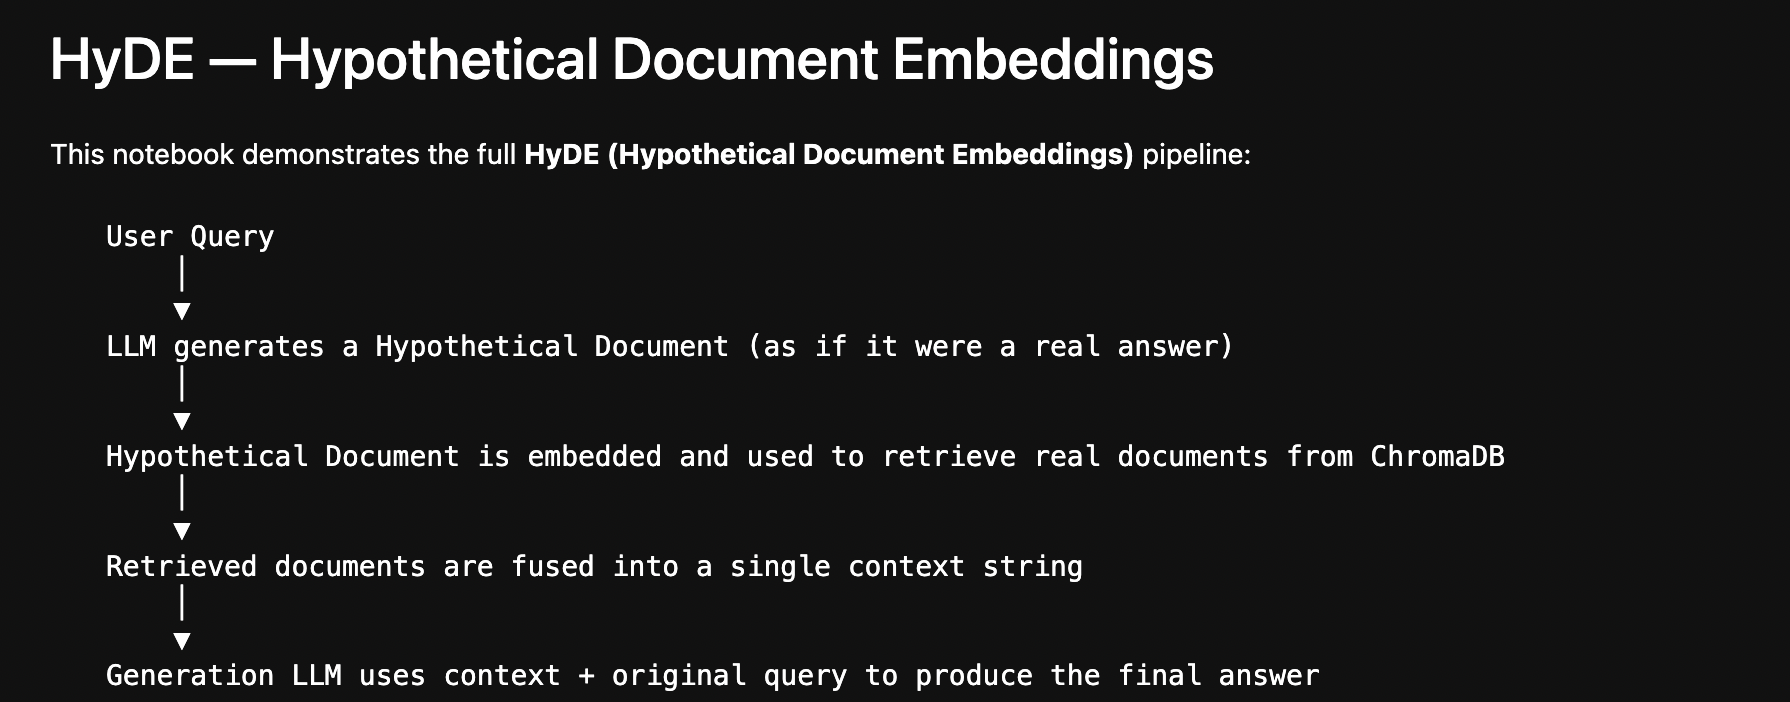

In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from hyde import CustomHypotheticalDocumentEmbedder

In [2]:
load_dotenv()

True

In [3]:
documents = [
    # --- AI ---
    Document(
        page_content=(
            "The Transformer architecture, introduced in 'Attention Is All You Need' (Vaswani et al., 2017), "
            "replaces recurrent layers entirely with self-attention mechanisms. Each token attends to every "
            "other token in the sequence simultaneously, computing weighted sums based on query-key dot products. "
            "This parallelism enables efficient training on long sequences and has become the backbone of modern LLMs."
        ),
        metadata={"source": "AI", "topic": "Transformers"}
    ),
    Document(
        page_content=(
            "Multi-head attention allows the model to jointly attend to information from different representation "
            "subspaces at different positions. Each head learns distinct attention patterns — some heads track "
            "syntactic dependencies while others capture semantic relationships. The outputs of all heads are "
            "concatenated and linearly projected to produce the final representation."
        ),
        metadata={"source": "AI", "topic": "Attention Mechanisms"}
    ),
    Document(
        page_content=(
            "Reinforcement Learning from Human Feedback (RLHF) is a training paradigm where a reward model "
            "is first trained on human preference data, then used to fine-tune a language model via PPO. "
            "This process aligns model outputs with human values and has been central to making LLMs like "
            "ChatGPT safe and helpful in practice."
        ),
        metadata={"source": "AI", "topic": "RLHF"}
    ),
    Document(
        page_content=(
            "Retrieval-Augmented Generation (RAG) combines a retrieval system with a generative model. "
            "Given a query, relevant documents are fetched from an external knowledge base and prepended "
            "to the prompt as context. This grounds the model's response in factual information and reduces "
            "hallucination without requiring costly retraining."
        ),
        metadata={"source": "AI", "topic": "RAG"}
    ),
    Document(
        page_content=(
            "Large Language Models (LLMs) are trained on massive text corpora using next-token prediction. "
            "Scaling laws show that model performance improves predictably with increases in parameters, "
            "data, and compute. Emergent capabilities — such as few-shot reasoning and chain-of-thought — "
            "appear at certain scale thresholds and were not explicitly trained for."
        ),
        metadata={"source": "AI", "topic": "LLMs"}
    ),

    # --- Physics ---
    Document(
        page_content=(
            "Quantum entanglement is a phenomenon where two or more particles become correlated such that "
            "the quantum state of one cannot be described independently of the others, even when separated "
            "by large distances. Measuring one particle's state instantaneously determines the correlated "
            "property of the other, a fact Einstein famously called 'spooky action at a distance'."
        ),
        metadata={"source": "Physics", "topic": "Quantum Entanglement"}
    ),
    Document(
        page_content=(
            "A black hole is a region of spacetime where gravity is so strong that nothing — not even light — "
            "can escape once it crosses the event horizon. Stellar black holes form when massive stars collapse "
            "under their own gravity. Supermassive black holes, found at the centres of most galaxies, "
            "can contain billions of solar masses and are thought to power quasars."
        ),
        metadata={"source": "Physics", "topic": "Black Holes"}
    ),
    Document(
        page_content=(
            "The second law of thermodynamics states that the total entropy of an isolated system never decreases "
            "over time. Entropy can be understood as a measure of disorder or the number of microscopic "
            "configurations consistent with a macroscopic state. This law underpins the irreversibility of "
            "natural processes such as heat flow and chemical reactions."
        ),
        metadata={"source": "Physics", "topic": "Thermodynamics"}
    ),
    Document(
        page_content=(
            "Einstein's special theory of relativity postulates that the laws of physics are identical in all "
            "inertial frames and that the speed of light in a vacuum is constant regardless of the observer's "
            "motion. Consequences include time dilation, length contraction, and the equivalence of mass and "
            "energy expressed as E = mc²."
        ),
        metadata={"source": "Physics", "topic": "Special Relativity"}
    ),

    # --- Tech ---
    Document(
        page_content=(
            "Microservices architecture structures an application as a collection of small, independently "
            "deployable services, each responsible for a specific business capability. Services communicate "
            "over lightweight APIs (typically HTTP/REST or gRPC). This approach improves fault isolation, "
            "enables technology heterogeneity, and allows teams to scale individual components independently."
        ),
        metadata={"source": "Tech", "topic": "Microservices"}
    ),
    Document(
        page_content=(
            "Kubernetes is an open-source container orchestration platform that automates the deployment, "
            "scaling, and management of containerised applications. It groups containers into Pods, manages "
            "their lifecycle via controllers, and exposes them through Services. The control plane maintains "
            "the desired state of the cluster using a reconciliation loop."
        ),
        metadata={"source": "Tech", "topic": "Kubernetes"}
    ),
    Document(
        page_content=(
            "LLM inference at scale requires specialised hardware and serving strategies. Tensor parallelism "
            "splits model weights across multiple GPUs to fit large models in memory. Continuous batching "
            "improves GPU utilisation by dynamically grouping requests. Quantisation (INT8/INT4) reduces "
            "memory footprint at the cost of minor precision loss, enabling deployment on fewer accelerators."
        ),
        metadata={"source": "Tech", "topic": "LLM Inference"}
    ),
    Document(
        page_content=(
            "Modern semiconductor fabrication uses extreme ultraviolet (EUV) lithography to etch features "
            "at the 3–5 nm process node. TSMC and Samsung lead production at these scales. Each wafer "
            "passes through hundreds of deposition, etching, and doping steps inside cleanrooms rated "
            "ISO Class 1. Yield improvement is critical: a single defect can render an entire die unusable."
        ),
        metadata={"source": "Tech", "topic": "Semiconductors"}
    ),

    # --- Medicine ---
    Document(
        page_content=(
            "CRISPR-Cas9 is a genome editing tool derived from a bacterial immune defence mechanism. "
            "A guide RNA directs the Cas9 nuclease to a specific DNA sequence, where it introduces a "
            "double-strand break. The cell's repair machinery then inserts, deletes, or replaces genetic "
            "material. Clinical trials are underway for sickle cell disease, certain cancers, and "
            "hereditary blindness."
        ),
        metadata={"source": "Medicine", "topic": "CRISPR"}
    ),
    Document(
        page_content=(
            "mRNA vaccines work by delivering synthetic messenger RNA into cells, instructing them to "
            "produce a target antigen (e.g., the SARS-CoV-2 spike protein). The immune system mounts a "
            "response against the antigen, creating memory cells. The mRNA itself degrades within days "
            "and does not integrate into the host genome, making this platform both effective and safe."
        ),
        metadata={"source": "Medicine", "topic": "mRNA Vaccines"}
    ),
    Document(
        page_content=(
            "Brain-computer interfaces (BCIs) record neural signals and translate them into control commands "
            "for external devices. Implanted electrode arrays such as Utah arrays can record from hundreds "
            "of neurons simultaneously. Clinical applications include restoring motor function in paralysed "
            "patients and treating refractory depression via deep brain stimulation."
        ),
        metadata={"source": "Medicine", "topic": "Neural Implants"}
    ),
    Document(
        page_content=(
            "Antibiotic resistance arises when bacteria evolve mechanisms to survive drug exposure — including "
            "enzymatic drug inactivation, efflux pumps, and target modification. Overuse and misuse of "
            "antibiotics accelerates resistance. The WHO classifies antimicrobial resistance as one of the "
            "greatest global health threats, with carbapenem-resistant Enterobacteriaceae among the most "
            "critical pathogens."
        ),
        metadata={"source": "Medicine", "topic": "Antibiotic Resistance"}
    ),
]

print(f"Total documents loaded: {len(documents)}")


Total documents loaded: 17


### ChromaDB Vector Store Setup
All documents are embedded with text-embedding-3-small and stored in an in-memory ChromaDB collection.

In [4]:
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embedding_model,
    collection_name="hyde_demo"
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

print("ChromaDB collection ready.")

ChromaDB collection ready.


## HyDE Retriever Instantiatio

- document_llm — used internally by CustomHypotheticalDocumentEmbedder to generate the hypothetical document from the query.
- generation_llm — used later in the RAG generation step to produce the final answer.

In [5]:
document_llm = ChatOpenAI(model="gpt-5-mini", temperature=0)
generation_llm = ChatOpenAI(model="gpt-5-mini", temperature=0.5)

hyde_retriever = CustomHypotheticalDocumentEmbedder.from_llm(
    llm=document_llm,
    retriever=retriever
)

print("HyDE retriever ready.")

HyDE retriever ready.


### HyDE Retrieval

The query is passed to hyde_retriever.invoke(), which internally:

1. Generates a hypothetical document via document_llm
2. Embeds it and queries ChromaDB
3. Returns the top-3 most similar real documents

In [6]:
query = "How do transformer models use attention to process sequences?"

retrieved_docs = hyde_retriever.invoke(query)

for i, doc in enumerate(retrieved_docs):
    print(f"--- Doc {i + 1} | Source: {doc.metadata.get('source')} | Topic: {doc.metadata.get('topic')} ---")
    print(doc.page_content)
    print()

--- Doc 1 | Source: AI | Topic: Transformers ---
The Transformer architecture, introduced in 'Attention Is All You Need' (Vaswani et al., 2017), replaces recurrent layers entirely with self-attention mechanisms. Each token attends to every other token in the sequence simultaneously, computing weighted sums based on query-key dot products. This parallelism enables efficient training on long sequences and has become the backbone of modern LLMs.

--- Doc 2 | Source: AI | Topic: Attention Mechanisms ---
Multi-head attention allows the model to jointly attend to information from different representation subspaces at different positions. Each head learns distinct attention patterns — some heads track syntactic dependencies while others capture semantic relationships. The outputs of all heads are concatenated and linearly projected to produce the final representation.

--- Doc 3 | Source: AI | Topic: LLMs ---
Large Language Models (LLMs) are trained on massive text corpora using next-token pr

### Context Fusion

Retrieved documents are concatenated into a single context string, separated by double newlines.

In [7]:
context = "\n\n".join(doc.page_content for doc in retrieved_docs)

print("=== Fused Context ===")
print(context)

=== Fused Context ===
The Transformer architecture, introduced in 'Attention Is All You Need' (Vaswani et al., 2017), replaces recurrent layers entirely with self-attention mechanisms. Each token attends to every other token in the sequence simultaneously, computing weighted sums based on query-key dot products. This parallelism enables efficient training on long sequences and has become the backbone of modern LLMs.

Multi-head attention allows the model to jointly attend to information from different representation subspaces at different positions. Each head learns distinct attention patterns — some heads track syntactic dependencies while others capture semantic relationships. The outputs of all heads are concatenated and linearly projected to produce the final representation.

Large Language Models (LLMs) are trained on massive text corpora using next-token prediction. Scaling laws show that model performance improves predictably with increases in parameters, data, and compute. Emer

### Generation Phase

The fused context and original query are passed to generation_llm to produce a grounded final answer.

In [8]:
generation_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a helpful assistant. Answer the user's question using only the provided context. "
        "Be concise and accurate. If the context does not contain enough information, say so."
    ),
    ("human", "Context:\n{context}\n\nQuestion: {query}")
])

generation_chain = generation_prompt | generation_llm

response = generation_chain.invoke({"context": context, "query": query})

print("=== Final Answer ===")
print(response.content)

=== Final Answer ===
Transformers process sequences with self-attention: for each token the model computes queries, keys and values so that the token "attends" to every other token in the sequence simultaneously. Attention weights are computed from query–key dot products and used to form weighted sums of the values, producing a context-aware representation for each token. Multi-head attention runs several such attention mechanisms in parallel so the model can capture different kinds of relationships (e.g., syntactic vs. semantic) in different representation subspaces; the heads' outputs are concatenated and linearly projected to yield the final token representations. This parallel attention over all token pairs enables efficient training on long sequences.


![Screenshot 2026-05-21 at 8.28.52 PM.png](<attachment:Screenshot 2026-05-21 at 8.28.52 PM.png>)
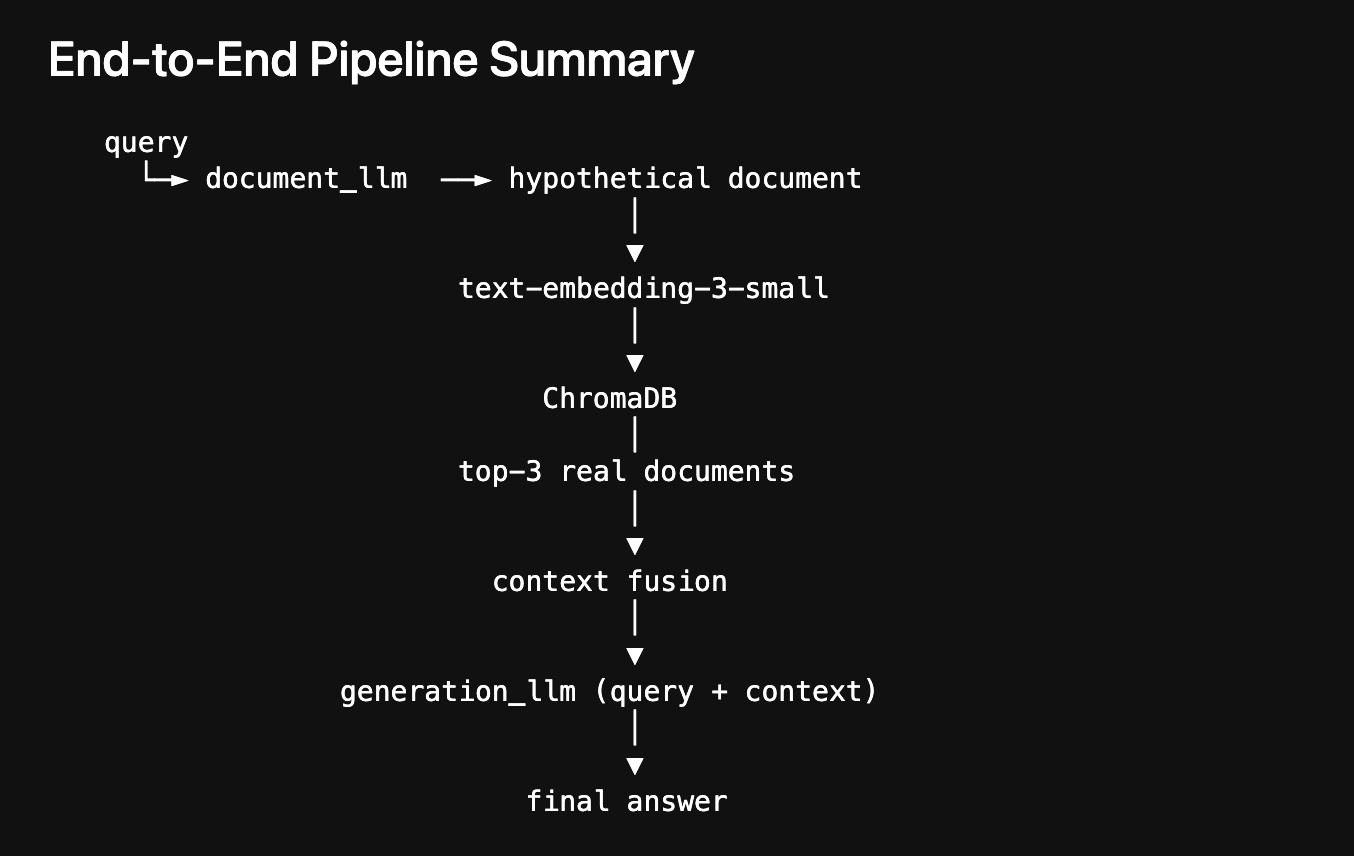